# Simple Langgraph Chat

In [1]:
%pip install langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from dotenv import load_dotenv

load_dotenv()

OPEN_LLM_MODEL = 'gpt-4.1-mini'

## 상태 state 정의

In [2]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# LangGraph의 State는 그래프 전체가 공유하는 상태 저장 공간이다.
# 여기서는 대화 메세지 목록만 상태로 관리한다.
class State(TypedDict):

    # message 필드에 reducer를 저장하는 방식이다.
    # add_messages는 새 메세지가 들어올 때 기존 messages를 덮어쓰지 말고, 기존 메세지 목록 뒤에 새 메세지를 추가한다.
    messages : Annotated[list[AnyMessage],add_messages]

## 챗봇 노드 정의

In [3]:
from langchain_openai import ChatOpenAI

# HumanMessage를 받아 AIMessage를 반환하는 Chatmodel 객체
llm = ChatOpenAI(model=OPEN_LLM_MODEL)

def chatbot(state:State):
    # 현재 State에서 messages를 꺼내 LLM에게 전달한다.
    # state['messages']에는 Humanmessages, AImessages 등이 순서대로 등러 있다.
    response = llm.invoke(state['messages'])

    # LanGraph의 노드는 State 전체를 직접 수정하지 않고, 업데이트 할 State 일부를 dict 형태로 변환한다.
    # messages 필드에는 add_messages reducer가 적용되어 있으므로, 새 메세지만 변환해도 기존 messages 뒤에 자동으로 추가 된다.
    return {'messages' : [response]}

## 그래프 구성/컴파일

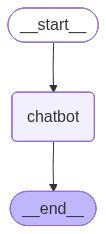

In [5]:
from langgraph.graph import StateGraph, START, END

# Langgraph는 지정한 state 구조를 기준으로 그래프를 만든다.
workflow = StateGraph(State)

# chatbot이라는 이름의 노드를 추가한다.
workflow.add_node("chatbot",chatbot)

# START는 그래프 시작 지점이다.
# 그래프가 실행되면 START에서 chatbot 노드로 이동한다.
workflow.add_edge(START,'chatbot')

# catbot 노드 실행이 끝나면 END로 이동해서 그래프 실행이 종료된다.
workflow.add_edge('chatbot',END)

# compile()을 호출하면 실행 가능한 그래프 객체가 만들어 진다.
graph = workflow.compile()

graph

## 그래프 실행

In [7]:
from langchain_core.messages import HumanMessage

user_input = '랭그래프가 뭔가요? 모르면 모른다고 답해주세요.'

initial_state = {
    'messages' : [
        HumanMessage(content=user_input)
    ]
}

# 그래프 설정
final_state = graph.invoke(initial_state)

final_state

{'messages': [HumanMessage(content='랭그래프가 뭔가요? 모르면 모른다고 답해주세요.', additional_kwargs={}, response_metadata={}, id='aeb29228-6f31-4b17-8fa2-d0dea210978f'),
  AIMessage(content="랭그래프에 대해 제가 가지고 있는 정보에는 명확한 정의나 설명이 없습니다. 혹시 '랭그래프'가 특정 분야나 용어라면, 더 자세한 맥락을 알려주시면 도움이 될 것 같습니다.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 25, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_65ba449743', 'id': 'chatcmpl-DfgTuePgbmG0zxDslCpvLg8dMUqio', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2a5b-c6b1-7851-863b-670283082b99-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 25, 'output_tokens': 52, 'total_to